# EDA de Alertas MTA

## Objetivo
Construir un análisis exploratorio reproducible y de alto nivel para alertas del metro de NYC, cargando datos directamente desde MinIO (bucket `pd1`) y generando hallazgos accionables para integrar con GTFS cleaned.

## 0) Setup y configuración
Este notebook no asume datasets locales. Toda la lectura se realiza desde MinIO usando helpers del proyecto en `src.common.minio_client`.

In [2]:
import os, sys
import re
import json
import tempfile
from pathlib import Path
from collections import Counter
from typing import Iterable, List, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 120)
warnings_filter = 'ignore'

print('✓ Librerías cargadas')

✓ Librerías cargadas


## 1) Carga de datos y preparación

In [4]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

# Descargar datos
START_DATE = "2025-01-10"
END_DATE = "2025-01-30"

dates = pd.date_range(start=START_DATE, end=END_DATE).strftime("%Y-%m-%d").tolist()

dfs = []

for SERVICE_DATE in dates:
    sched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_scheduled/date={SERVICE_DATE}/gtfs_scheduled_{SERVICE_DATE}.parquet")
    unsched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_unscheduled/date={SERVICE_DATE}/gtfs_unscheduled_{SERVICE_DATE}.parquet")
    sched['dataset_type'] = 'scheduled'
    unsched['dataset_type'] = 'unscheduled'
    dfs.extend([sched, unsched])

df_gtfs = pd.concat(dfs, ignore_index=True)

In [5]:
dfs = []
empty_dates = []
missing_dates = []

for SERVICE_DATE in dates:
    base = f"grupo5/cleaned/official_alerts/date={SERVICE_DATE}"
    main_path = f"{base}/alerts.parquet"
    empty_path = f"{base}/_empty.parquet"

    df_day = None

    # Intentar el parquet con datos
    try:
        df_day = download_df_parquet(access_key, secret_key, main_path)
    except Exception:
        # Si no está, intentar el _empty.parquet
        try:
            df_day = download_df_parquet(access_key, secret_key, empty_path)
            empty_dates.append(SERVICE_DATE)
        except Exception:
            missing_dates.append(SERVICE_DATE)
            continue

    df_day["service_date"] = SERVICE_DATE

    # Si viene vacío, lo omitimos
    if df_day is None or len(df_day) == 0:
        empty_dates.append(SERVICE_DATE)
        continue

    dfs.append(df_day)

df_alerts = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

print(f"Días con _empty.parquet: {empty_dates}")
print(f"Días sin ningún parquet: {missing_dates}")

Días con _empty.parquet: []
Días sin ningún parquet: []


In [6]:
# Convertir strings a formato datetime de Pandas
df_alerts['timestamp_start'] = pd.to_datetime(df_alerts['timestamp_start'])
# Si una alerta no tiene fin, le ponemos una fecha muy lejana para que siga activa
df_alerts['timestamp_end'] = pd.to_datetime(df_alerts['timestamp_end']).fillna(pd.Timestamp.max)

# Separar las líneas por coma, quitar espacios y "explotar" la lista a filas individuales
df_alerts['route_id'] = df_alerts['lines'].astype(str).str.replace(' ', '').str.split(',')
df_alerts_exp = df_alerts.explode('route_id')

In [ ]:
# Crear Banderas (Flags) de Severidad (Feature Engineering)
# Convertimos el texto de la categoría en variables numéricas para el modelo
df_alerts_exp['alert_delay'] = (df_alerts_exp['category'] == 'Delay').astype(int)
df_alerts_exp['alert_suspension'] = (df_alerts_exp['category'] == 'Suspension').astype(int)

# Cruzamos por Fecha y por Ruta para reducir el tamaño del cruce
df_full = pd.merge(
    df_gtfs[['match_key', 'stop_id', 'service_date', 'route_id', 'delay_seconds', 'lagged_delay_1', 'actual_headway_seconds', 'headway_ratio', 'is_unscheduled'
             'lagged_delay_2', 'route_rolling_delay', 'rolling_mean_delay_trip', 'hour', 'is_peak', 'dow', 'trip_progress', 'is_weekend', 'actual_seconds']],
    df_alerts_exp[['event_id', 'timestamp_start','timestamp_end','route_id', 'category', 'lines', 'service_date', 'alert_suspension', 'alert_delay']], 
    on=['service_date', 'route_id'], 
    how='left'
)

# Recrear el timestamp exacto del tren
df_full['arrival_dt'] = pd.to_datetime(df_full['service_date']) + pd.to_timedelta(df_full['actual_seconds'], unit='s')

# Solo nos quedamos con el cruce si el tren pasó mientras la alerta estaba viva
# para evitar data leakage
mask_active = (df_full['arrival_dt'] >= df_full['timestamp_start']) & (df_full['arrival_dt'] <= df_full['timestamp_end'])

# Aplicar la máscara
df_full.loc[~mask_active, ['event_id', 'category', 'alert_delay', 'alert_suspension']] = np.nan

c:\Users\2alex\c2526-R5\.venv\Lib\site-packages\pandas\core\arrays\timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


In [8]:
print('Columnas disponibles:')
print(sorted(df_full.columns.tolist()))

dtype_summary = pd.DataFrame({
    'column': df_full.columns,
    'dtype': [str(t) for t in df_full.dtypes],
    'non_null': df_full.count().values,
    '%_null': (df_full.isna().mean().values * 100).round(2)
}).sort_values('%_null', ascending=False)

display(dtype_summary.head(40))
display(df_full.head(3))

Columnas disponibles:
['actual_headway_seconds', 'actual_seconds', 'alert_delay', 'alert_suspension', 'arrival_dt', 'category', 'delay_seconds', 'dow', 'event_id', 'headway_ratio', 'hour', 'is_peak', 'is_weekend', 'lagged_delay_1', 'lagged_delay_2', 'lines', 'match_key', 'rolling_mean_delay_trip', 'route_id', 'route_rolling_delay', 'service_date', 'stop_id', 'timestamp_end', 'timestamp_start', 'trip_progress']


,column,dtype,non_null,%_null
22,alert_suspension,float64,17504,99.95
17,event_id,str,17504,99.95
20,category,str,17504,99.95
23,alert_delay,float64,17504,99.95
8,lagged_delay_2,float64,32985206,9.79
10,rolling_mean_delay_trip,float64,33812416,7.53
5,lagged_delay_1,float64,34093077,6.76
4,delay_seconds,float64,34876366,4.62
9,route_rolling_delay,float64,34883692,4.60
21,lines,str,35237892,3.63


,match_key,stop_id,service_date,route_id,delay_seconds,lagged_delay_1,actual_headway_seconds,headway_ratio,lagged_delay_2,route_rolling_delay,rolling_mean_delay_trip,hour,is_peak,dow,trip_progress,is_weekend,actual_seconds,event_id,timestamp_start,timestamp_end,category,lines,alert_suspension,alert_delay,arrival_dt
0,030100_4..N01R,257N,2025-01-10,4,NaN,-311.0,NaN,NaN,-305.0,NaN,NaN,5,0,4,0.0,0,NaN,NaN,2025-01-10 01:48:00,2025-01-10 01:48:00,NaN,4,NaN,NaN,NaT
1,030100_4..N01R,257N,2025-01-10,4,NaN,-311.0,NaN,NaN,-305.0,NaN,NaN,5,0,4,0.0,0,NaN,NaN,2025-01-10 02:10:00,2025-01-10 02:10:00,NaN,4,NaN,NaN,NaT
2,030100_4..N01R,257N,2025-01-10,4,NaN,-311.0,NaN,NaN,-305.0,NaN,NaN,5,0,4,0.0,0,NaN,NaN,2025-01-10 06:59:00,2025-01-10 06:59:00,NaN,"4, 6",NaN,NaN,NaT


## 2) Análisis temporal

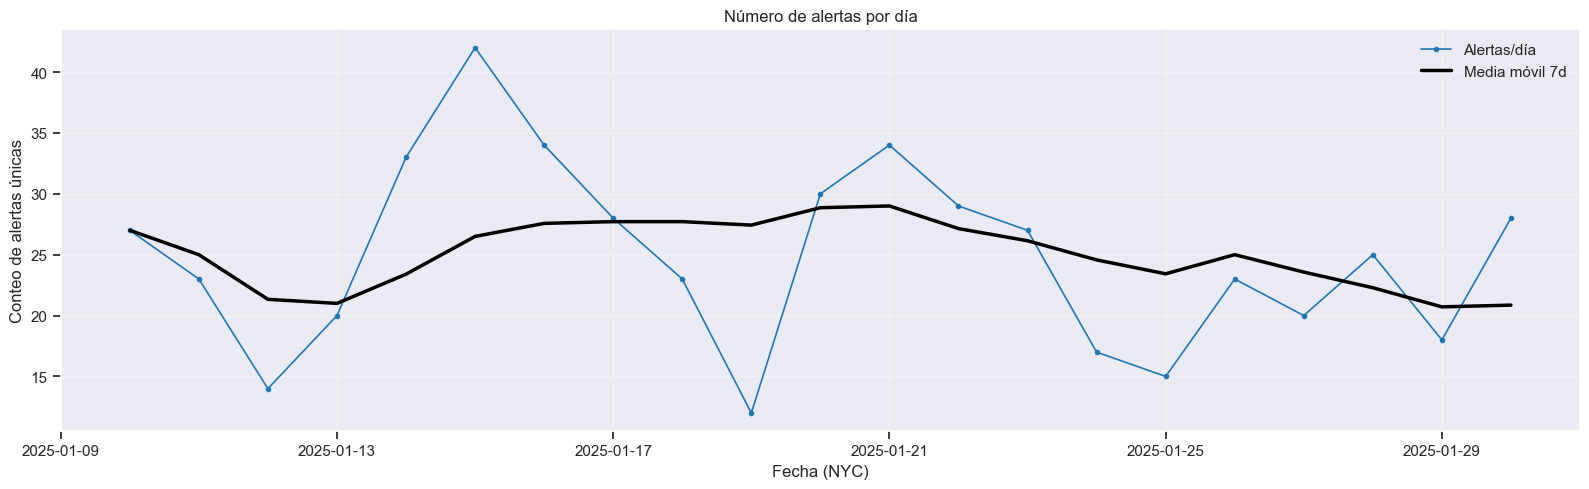

In [9]:
daily_alerts = df_full.groupby('service_date')['event_id'].nunique().sort_index()
daily_alerts.index = pd.to_datetime(daily_alerts.index, errors='coerce')
daily_ma7 = daily_alerts.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily_alerts.index, daily_alerts.values, marker='o', markersize=3, linewidth=1.2, label='Alertas/día')
ax.plot(daily_ma7.index, daily_ma7.values, linewidth=2.5, color='black', label='Media móvil 7d')
ax.set_title('Número de alertas por día')
ax.set_xlabel('Fecha (NYC)')
ax.set_ylabel('Conteo de alertas únicas')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

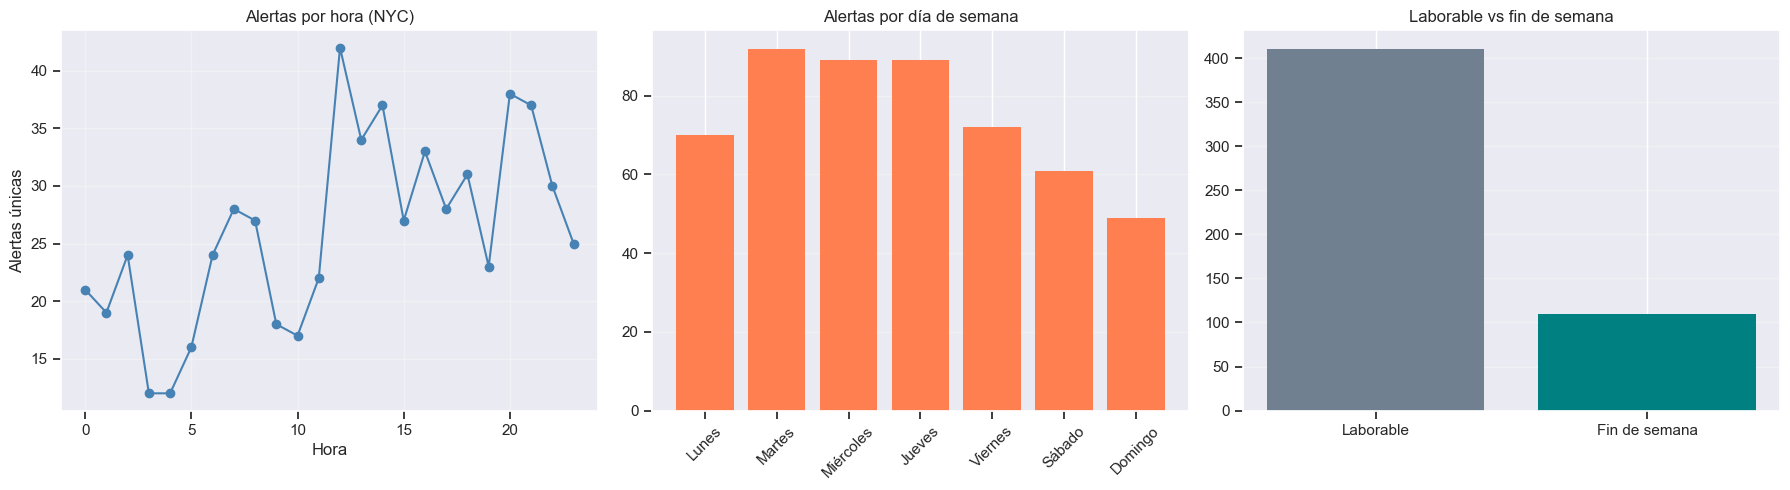

In [10]:
dow_map = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}

hourly = df_full.groupby('hour')['event_id'].nunique().reindex(range(24), fill_value=0)
dow_counts = df_full.groupby('dow')['event_id'].nunique().reindex(range(7), fill_value=0)
weekend_comp = df_full.groupby('is_weekend')['event_id'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue')
axes[0].set_title('Alertas por hora (NYC)')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Alertas únicas')
axes[0].grid(alpha=0.3)

axes[1].bar([dow_map[i] for i in dow_counts.index], dow_counts.values, color='coral')
axes[1].set_title('Alertas por día de semana')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

labels = ['Laborable', 'Fin de semana']
vals = [weekend_comp.get(0, 0), weekend_comp.get(1, 0)]
axes[2].bar(labels, vals, color=['slategray', 'teal'])
axes[2].set_title('Laborable vs fin de semana')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

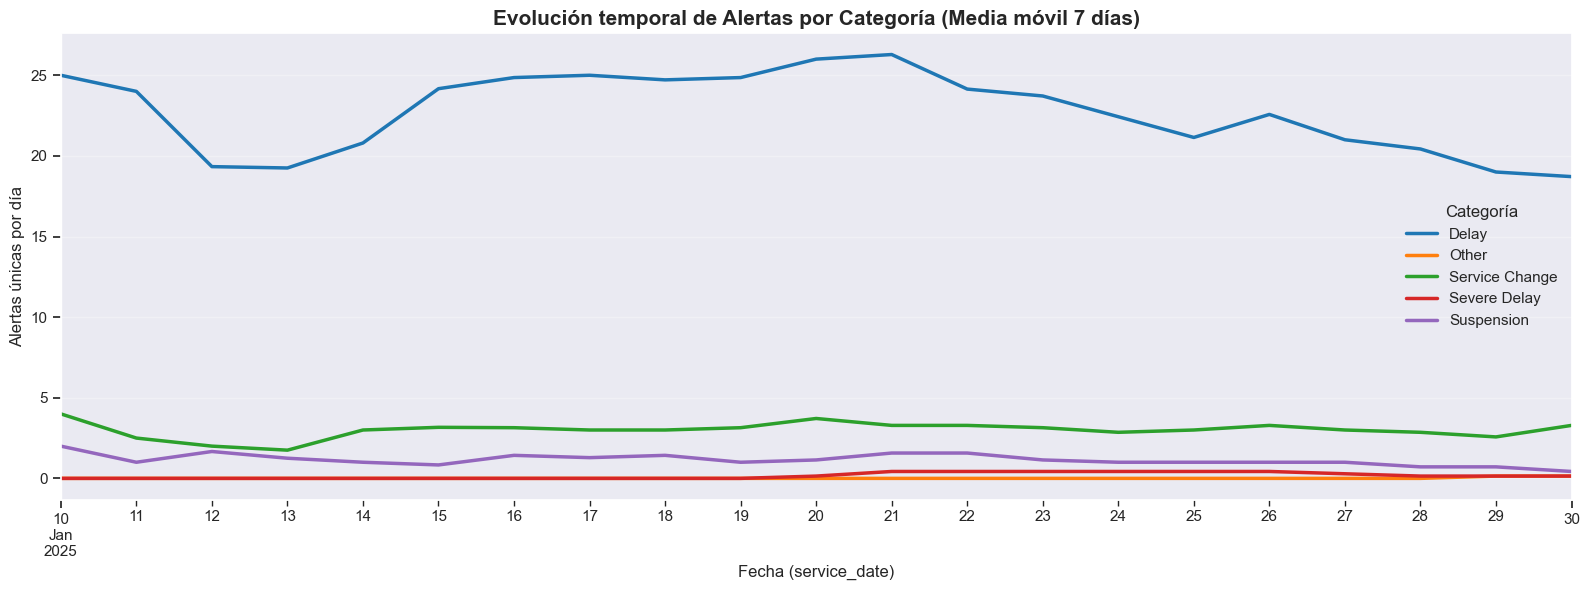

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sacamos las 5 categorías principales de vuestro dataset real
top_categories = df_full['category'].value_counts().head(5).index.tolist()

# 2. Agrupamos usando 'event_id' (que es vuestro ID real) y 'service_date'
cat_time = (df_full[df_full['category'].isin(top_categories)]
            .groupby(['service_date', 'category'])['event_id']
            .nunique()
            .unstack(fill_value=0))

# Asegurarnos de que el índice es formato fecha
cat_time.index = pd.to_datetime(cat_time.index, errors='coerce')

# 3. Dibujamos una única gráfica clara y profesional (Media móvil de 7 días)
plt.figure(figsize=(16, 6))
cat_time.rolling(7, min_periods=1).mean().plot(linewidth=2.5, ax=plt.gca())

plt.title('Evolución temporal de Alertas por Categoría (Media móvil 7 días)', fontsize=15, fontweight='bold')
plt.ylabel('Alertas únicas por día', fontsize=12)
plt.xlabel('Fecha (service_date)', fontsize=12)
plt.legend(title='Categoría', fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

### Conclusiones temporales
- La curva diaria y su media móvil de 7 días ayudan a separar ruido operativo de tendencias estructurales.
- Los patrones por hora y día revelan ventanas donde las alertas se concentran y pueden impactar más al servicio.
- La segmentación por `category` y `effect` permite identificar si los picos vienen por incidencias puntuales o por trabajos planificados.

## 3) Relación entre alertas y desempeño operacional (delay/headway/delay futuro)

En esta sección analizamos si la presencia e intensidad de alertas se asocia con:
- `delay_seconds`
- `actual_headway_seconds` y `headway_ratio`
- targets de delay futuro (si existen en el merge)

> Nota: el merge por `service_date + route_id` puede generar múltiples filas por observación GTFS si hay varias alertas activas. Por eso agregamos a nivel de `match_key` para evitar sobreconteo.

In [12]:
# 3.1 Preparar dataset de análisis a nivel observación GTFS
if 'match_key' not in df_full.columns:
    df_full = df_full.copy()
    df_full['match_key'] = np.arange(len(df_full)).astype(str)

future_candidates = [
    'target_delay_10m', 'target_delay_20m', 'target_delay_30m', 'target_delay_end',
    'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m'
]

# Si faltan targets futuros en df_full pero existen en df_gtfs, los añadimos por match_key
future_missing = [c for c in future_candidates if c not in df_full.columns]
future_in_gtfs = [c for c in future_missing if ('df_gtfs' in globals() and c in df_gtfs.columns)]
if future_in_gtfs and 'match_key' in df_gtfs.columns:
    gtfs_future = df_gtfs[['match_key'] + future_in_gtfs].drop_duplicates('match_key')
    df_full = df_full.merge(gtfs_future, on='match_key', how='left')

numeric_base = [
    'delay_seconds', 'actual_headway_seconds', 'headway_ratio',
    'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'rolling_mean_delay_trip',
    'hour', 'is_peak', 'dow', 'trip_progress', 'is_weekend'
]
numeric_base = [c for c in numeric_base if c in df_full.columns]
future_cols = [c for c in future_candidates if c in df_full.columns]

alert_cols = [c for c in ['event_id', 'alert_delay', 'alert_suspension', 'category'] if c in df_full.columns]

agg_spec = {c: 'first' for c in numeric_base + future_cols}
if 'event_id' in alert_cols:
    agg_spec['event_id'] = pd.Series.nunique
if 'alert_delay' in alert_cols:
    agg_spec['alert_delay'] = 'max'
if 'alert_suspension' in alert_cols:
    agg_spec['alert_suspension'] = 'max'
if 'category' in alert_cols:
    agg_spec['category'] = lambda s: ', '.join(sorted({str(x) for x in s.dropna().astype(str)}))

df_rel = df_full.groupby('match_key', dropna=False).agg(agg_spec).reset_index()

if 'event_id' in df_rel.columns:
    df_rel = df_rel.rename(columns={'event_id': 'alert_count'})
else:
    df_rel['alert_count'] = 0

df_rel['alert_count'] = df_rel['alert_count'].fillna(0)
df_rel['has_alert'] = (df_rel['alert_count'] > 0).astype(int)

for c in ['alert_delay', 'alert_suspension']:
    if c in df_rel.columns:
        df_rel[c] = df_rel[c].fillna(0).astype(int)

print(f"Observaciones GTFS (match_key): {len(df_rel):,}")
print(f"Con alerta: {df_rel['has_alert'].sum():,} ({df_rel['has_alert'].mean()*100:.2f}%)")
print(f"Sin alerta: {(df_rel['has_alert']==0).sum():,}")
print('Targets de delay futuro disponibles:', future_cols if future_cols else 'Ninguno en el merge actual')

Observaciones GTFS (match_key): 39,571
Con alerta: 2,675 (6.76%)
Sin alerta: 36,896
Targets de delay futuro disponibles: ['target_delay_10m', 'target_delay_20m', 'target_delay_30m', 'target_delay_end', 'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m']


,metric,n_no_alert,n_with_alert,mean_no_alert,mean_with_alert,mean_diff,mean_diff_pct,median_no_alert,median_with_alert,median_diff
2,headway_ratio,36851,2674,2.243700,1.664595,-0.579105,-25.810250,1.0,1.0,0.0
0,delay_seconds,19424,2675,33.140445,28.993271,-4.147174,-12.513935,0.0,0.0,0.0
7,delta_delay_10m,11086,1429,30.691413,11.763471,-18.927942,-61.671784,13.0,0.0,-13.0
3,target_delay_10m,11086,1429,86.803085,65.850245,-20.952840,-24.138359,55.0,35.0,-20.0
1,actual_headway_seconds,36884,2675,499.959115,462.983925,-36.975190,-7.395643,411.0,381.0,-30.0
8,delta_delay_20m,8672,1378,55.102744,12.891872,-42.210872,-76.603938,30.0,-5.0,-35.0
9,delta_delay_30m,8572,1385,66.491951,18.554513,-47.937438,-72.095100,43.0,-3.0,-46.0
4,target_delay_20m,8672,1378,113.715982,64.638607,-49.077376,-43.157852,75.0,25.0,-50.0
5,target_delay_30m,8572,1385,124.913206,70.389892,-54.523314,-43.648959,90.0,21.0,-69.0
6,target_delay_end,19041,2672,91.079092,33.812126,-57.266967,-62.876084,6.0,-2.0,-8.0


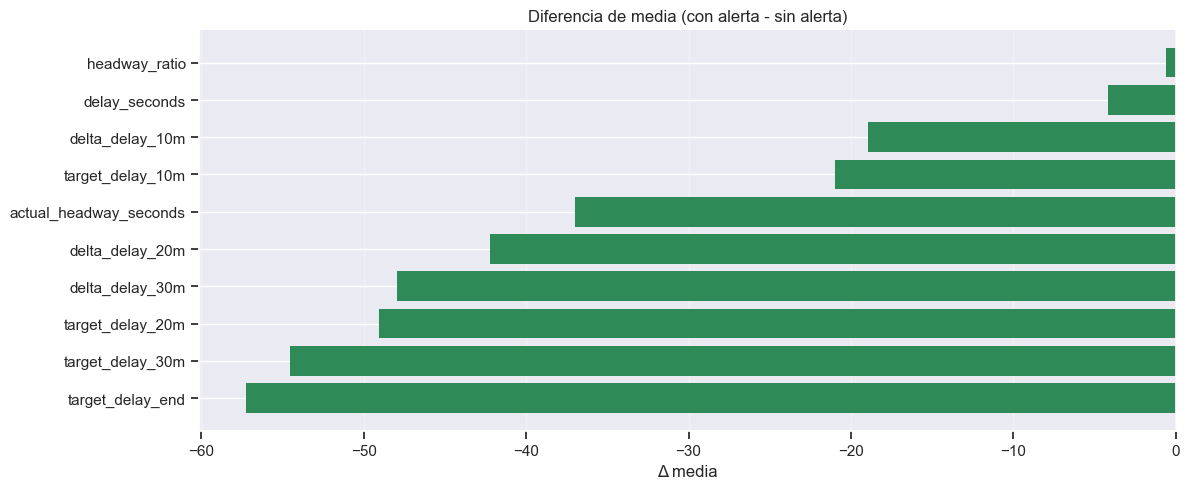

In [13]:
# 3.2 Comparativa directa: con alerta vs sin alerta
metrics_main = [c for c in ['delay_seconds', 'actual_headway_seconds', 'headway_ratio'] if c in df_rel.columns]
metrics_future = [c for c in ['target_delay_10m', 'target_delay_20m', 'target_delay_30m', 'target_delay_end'] if c in df_rel.columns]
metrics_delta = [c for c in ['delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m'] if c in df_rel.columns]
metrics_all = metrics_main + metrics_future + metrics_delta

comp_rows = []
for m in metrics_all:
    base = df_rel.loc[df_rel['has_alert'] == 0, m].dropna()
    treat = df_rel.loc[df_rel['has_alert'] == 1, m].dropna()
    if len(base) == 0 or len(treat) == 0:
        continue
    mean_base = base.mean()
    mean_treat = treat.mean()
    med_base = base.median()
    med_treat = treat.median()
    comp_rows.append({
        'metric': m,
        'n_no_alert': len(base),
        'n_with_alert': len(treat),
        'mean_no_alert': mean_base,
        'mean_with_alert': mean_treat,
        'mean_diff': mean_treat - mean_base,
        'mean_diff_pct': ((mean_treat - mean_base) / mean_base * 100) if mean_base not in [0, np.nan] else np.nan,
        'median_no_alert': med_base,
        'median_with_alert': med_treat,
        'median_diff': med_treat - med_base
    })

comp_df = pd.DataFrame(comp_rows).sort_values('mean_diff', ascending=False) if comp_rows else pd.DataFrame()

display(comp_df)

if not comp_df.empty:
    fig, ax = plt.subplots(figsize=(12, max(4, 0.5 * len(comp_df))))
    plot_df = comp_df.sort_values('mean_diff')
    ax.barh(plot_df['metric'], plot_df['mean_diff'], color=np.where(plot_df['mean_diff'] >= 0, 'firebrick', 'seagreen'))
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title('Diferencia de media (con alerta - sin alerta)')
    ax.set_xlabel('Δ media')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

,has_alert,alert_count_capped,alert_delay,alert_suspension,delay_seconds,actual_headway_seconds,headway_ratio,target_delay_10m,target_delay_20m,target_delay_30m,target_delay_end
0,0,0,0,0,33.140,499.959,2.244,86.803,113.716,124.913,91.079
1,1,1,0,0,16.484,447.251,1.695,65.247,67.249,63.573,25.913
2,1,1,0,1,15.232,434.633,1.872,53.074,27.200,47.689,39.160
3,1,1,1,0,26.652,487.529,1.726,63.765,75.244,77.577,48.133
4,1,1,1,1,17.415,397.439,1.435,93.400,151.400,263.000,108.463
5,1,2,0,0,53.500,295.000,0.642,37.000,32.000,-105.500,-137.500
6,1,2,0,1,42.208,350.042,2.219,37.522,34.058,51.971,-60.083
7,1,2,1,0,38.365,441.555,1.324,66.863,56.527,70.809,3.200
8,1,2,1,1,17.546,514.598,1.072,23.308,-17.654,-13.346,74.113
9,1,3,0,1,458.400,511.200,3.310,361.500,369.000,248.700,-229.700


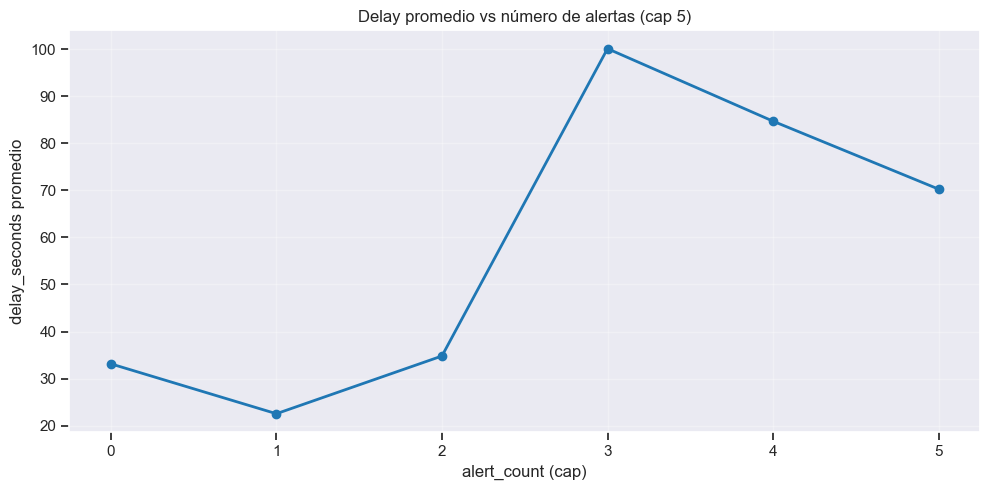

In [14]:
# 3.3 Intensidad de alertas y severidad vs métricas operativas
if 'alert_count' in df_rel.columns:
    df_rel['alert_count_capped'] = df_rel['alert_count'].clip(upper=5)

severity_cols = [c for c in ['alert_delay', 'alert_suspension'] if c in df_rel.columns]

group_cols = ['has_alert']
if 'alert_count_capped' in df_rel.columns:
    group_cols.append('alert_count_capped')
for c in severity_cols:
    group_cols.append(c)

metrics_focus = [c for c in ['delay_seconds', 'actual_headway_seconds', 'headway_ratio'] if c in df_rel.columns]
metrics_focus += [c for c in ['target_delay_10m', 'target_delay_20m', 'target_delay_30m', 'target_delay_end'] if c in df_rel.columns]

severity_summary = (
    df_rel.groupby(group_cols)[metrics_focus]
    .mean()
    .round(3)
    .reset_index()
    if metrics_focus else pd.DataFrame()
)

display(severity_summary.head(30))

if 'alert_count_capped' in df_rel.columns and 'delay_seconds' in df_rel.columns:
    fig, ax = plt.subplots(figsize=(10, 5))
    tmp = df_rel.groupby('alert_count_capped')['delay_seconds'].mean()
    ax.plot(tmp.index, tmp.values, marker='o', linewidth=2)
    ax.set_title('Delay promedio vs número de alertas (cap 5)')
    ax.set_xlabel('alert_count (cap)')
    ax.set_ylabel('delay_seconds promedio')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [15]:
df_alerts_exp.columns

Index(['event_id', 'timestamp_start', 'timestamp_end', 'category', 'lines',
       'text_snippet', 'description', 'num_updates', 'service_date',
       'route_id', 'alert_delay', 'alert_suspension'],
      dtype='str')

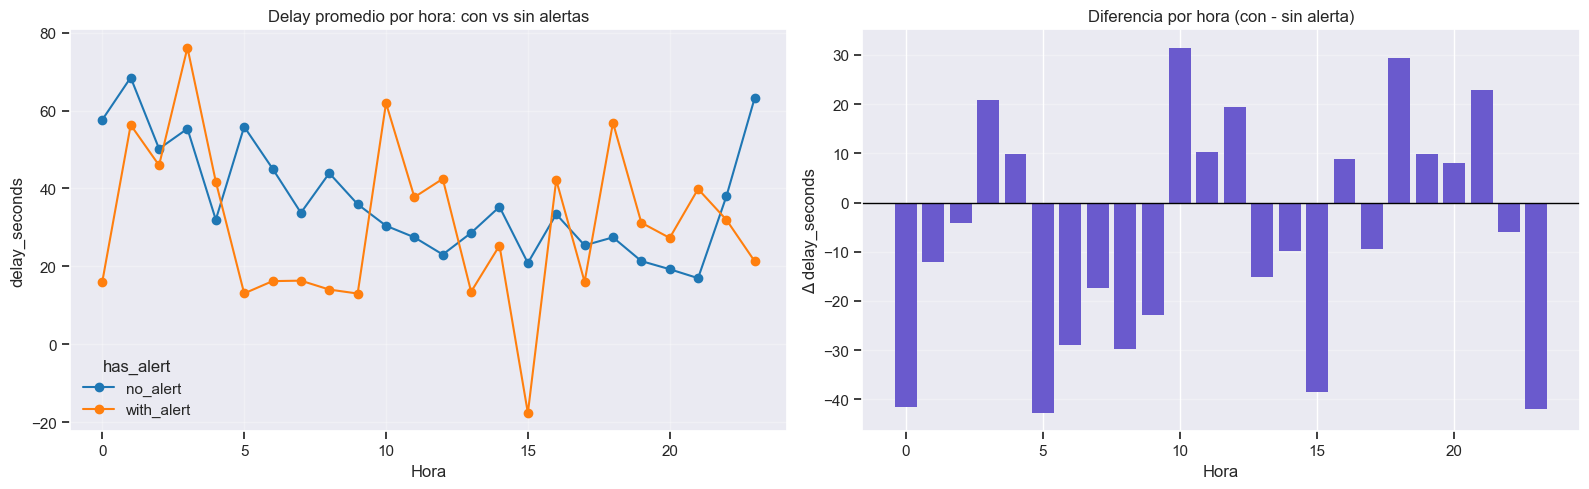

has_alert,no_alert,with_alert,diff
is_peak,,,
off_peak,33.124,30.507,-2.617
peak,33.163,26.349,-6.814


In [16]:
# 3.4 Control temporal: efecto condicional por hora y pico
if {'hour', 'delay_seconds', 'has_alert'}.issubset(df_rel.columns):
    hour_effect = (
        df_rel.groupby(['hour', 'has_alert'])['delay_seconds']
        .mean()
        .unstack(fill_value=np.nan)
        .rename(columns={0: 'no_alert', 1: 'with_alert'})
    )
    hour_effect['diff'] = hour_effect['with_alert'] - hour_effect['no_alert']

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    hour_effect[['no_alert', 'with_alert']].plot(ax=axes[0], marker='o')
    axes[0].set_title('Delay promedio por hora: con vs sin alertas')
    axes[0].set_xlabel('Hora')
    axes[0].set_ylabel('delay_seconds')
    axes[0].grid(alpha=0.3)

    axes[1].bar(hour_effect.index, hour_effect['diff'], color='slateblue')
    axes[1].axhline(0, color='black', linewidth=1)
    axes[1].set_title('Diferencia por hora (con - sin alerta)')
    axes[1].set_xlabel('Hora')
    axes[1].set_ylabel('Δ delay_seconds')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

if {'is_peak', 'delay_seconds', 'has_alert'}.issubset(df_rel.columns):
    peak_effect = df_rel.groupby(['is_peak', 'has_alert'])['delay_seconds'].mean().unstack(fill_value=np.nan)
    peak_effect = peak_effect.rename(index={0: 'off_peak', 1: 'peak'}, columns={0: 'no_alert', 1: 'with_alert'})
    peak_effect['diff'] = peak_effect['with_alert'] - peak_effect['no_alert']
    display(peak_effect.round(3))

### Conclusiones de relación alertas ↔ desempeño

- Si `mean_diff` en `delay_seconds` es positivo y consistente por hora/pico, hay evidencia descriptiva de asociación entre alertas y mayor retraso.
- Si `actual_headway_seconds` o `headway_ratio` aumentan con `has_alert`/`alert_count`, las alertas también se asocian con empeoramiento en regularidad de paso.
- Para delay futuro (`target_delay_*`), diferencias positivas sugieren persistencia del impacto más allá del instante actual.
- Importante: este análisis es correlacional (no causal). El siguiente paso es modelado controlado por línea, hora, día y estado previo (`lagged_delay_*`).

## 4) Filtro temporal estricto y shock reactivo vs proactivo

**Contexto de negocio**
Para evitar leakage, una alerta solo debe impactar al tren si estaba activa al momento exacto de su paso por estación. Además, diferenciamos shocks planificados (trabajos conocidos) vs no planificados (incidentes operativos) para separar efecto esperado de disrupción súbita.

In [21]:
# 4.1 Filtro temporal estricto + flags NLP de shock
df_full = df_full.copy()

# Normalización de tipos temporales
df_full['service_date'] = pd.to_datetime(df_full['service_date'], errors='coerce')
df_full['timestamp_start'] = pd.to_datetime(df_full['timestamp_start'], errors='coerce')
df_full['timestamp_end'] = pd.to_datetime(df_full['timestamp_end'], errors='coerce')

# Timestamp de paso del tren por estación
df_full['arrival_dt'] = df_full['service_date'] + pd.to_timedelta(df_full['actual_seconds'], unit='s', errors='coerce')

# Alerta activa SOLO si arrival_dt cae dentro del intervalo [start, end]
df_full['is_active_alert'] = (
    df_full['arrival_dt'].notna()
    & df_full['timestamp_start'].notna()
    & df_full['timestamp_end'].notna()
    & (df_full['arrival_dt'] >= df_full['timestamp_start'])
    & (df_full['arrival_dt'] <= df_full['timestamp_end'])
)


# Aplicar flags solo donde la alerta está activa
df_full['is_planned_work'] = 0
df_full['is_unplanned_shock'] = 0
active_idx = df_full['is_active_alert']

print('is_active_alert (share %):', round(df_full['is_active_alert'].mean() * 100, 2))
print('is_planned_work (activos):', int(df_full.loc[active_idx, 'is_planned_work'].sum()))
print('is_unplanned_shock (activos):', int(df_full.loc[active_idx, 'is_unplanned_shock'].sum()))

c:\Users\2alex\c2526-R5\.venv\Lib\site-packages\pandas\core\arrays\timedeltas.py:1163: RuntimeWarning: invalid value encountered in cast
  int_data = data.astype(np.int64)


is_active_alert (share %): 0.05
is_planned_work (activos): 0
is_unplanned_shock (activos): 0


## 5) El desfase de comunicación (Latencia de la MTA)

**Contexto de negocio**
Si el retraso promedio ya venía creciendo antes de `timestamp_start`, entonces la publicación oficial llega tarde respecto al inicio real del problema. El minuto 0 representa el momento del aviso oficial, no necesariamente el inicio operativo de la congestión.

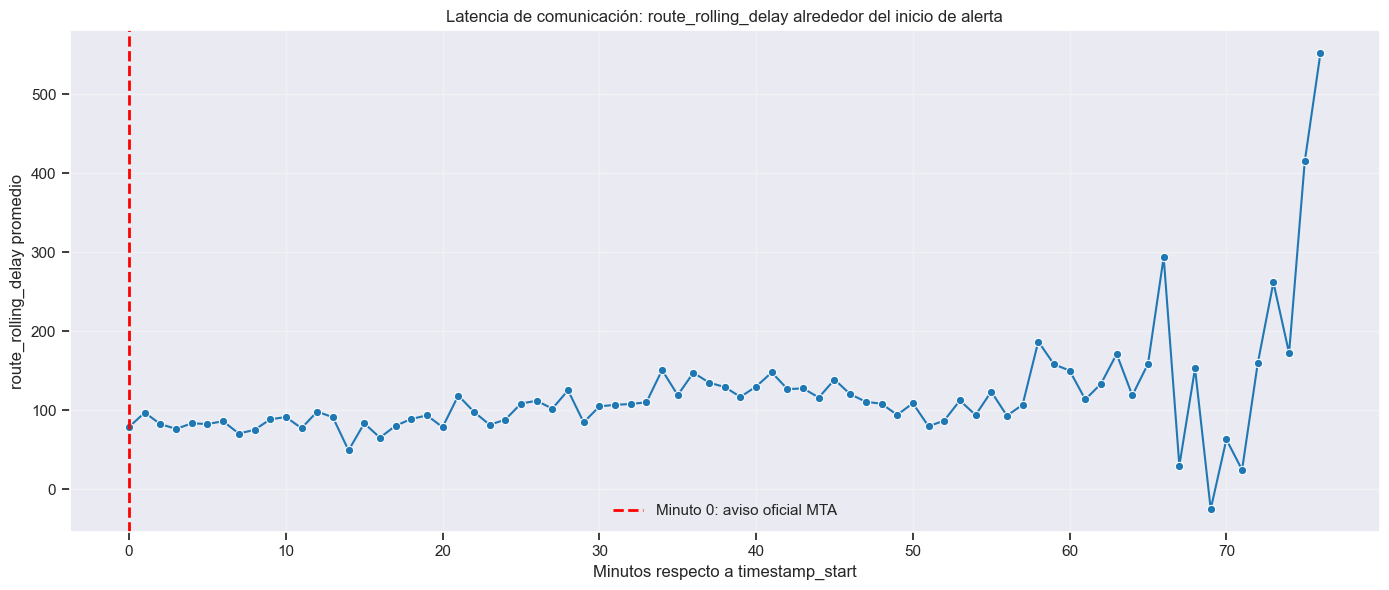

In [24]:
# 5.1 Evolución del delay alrededor del inicio de alertas no planificadas
shock_df = df_full.loc[df_full['is_active_alert'] == 1].copy()

# Eje temporal relativo al inicio oficial de la alerta (en minutos)
shock_df['mins_from_alert_start'] = (
    shock_df['arrival_dt'] - shock_df['timestamp_start']
).dt.total_seconds() / 60.0

shock_window = shock_df.loc[
    shock_df['mins_from_alert_start'].between(-90, 90, inclusive='both')
    & shock_df['route_rolling_delay'].notna()
].copy()

if shock_window.empty:
    print('No hay observaciones suficientes para la ventana [-90, +90] en shocks no planificados.')
else:
    shock_window['minute_from_start'] = shock_window['mins_from_alert_start'].round().astype(int)
    latency_curve = (
        shock_window.groupby('minute_from_start', as_index=False)['route_rolling_delay']
        .mean()
        .sort_values('minute_from_start')
    )

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=latency_curve, x='minute_from_start', y='route_rolling_delay', marker='o')
    plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Minuto 0: aviso oficial MTA')
    plt.title('Latencia de comunicación: route_rolling_delay alrededor del inicio de alerta')
    plt.xlabel('Minutos respecto a timestamp_start')
    plt.ylabel('route_rolling_delay promedio')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
df_full['category'].value_counts()

## 6) La respuesta operativa (¿Más trenes o evacuación?)

**Contexto de negocio**
Queremos verificar si la operación responde inyectando trenes no programados durante la crisis o, por el contrario, lo hace después de que termina la alerta para absorber acumulación de pasajeros en andenes.

In [28]:
# 6.1 % de trenes no programados por fase de alerta
op_df = df_full.copy()

valid_time = op_df['arrival_dt'].notna() & op_df['timestamp_start'].notna() & op_df['timestamp_end'].notna()
before_cond = valid_time & (op_df['arrival_dt'] >= (op_df['timestamp_start'] - pd.Timedelta(hours=1))) & (op_df['arrival_dt'] < op_df['timestamp_start'])
during_cond = valid_time & (op_df['arrival_dt'] >= op_df['timestamp_start']) & (op_df['arrival_dt'] <= op_df['timestamp_end'])
after_cond = valid_time & (op_df['arrival_dt'] > op_df['timestamp_end']) & (op_df['arrival_dt'] <= (op_df['timestamp_end'] + pd.Timedelta(hours=1)))

op_df['Fase Alerta'] = np.select(
    [before_cond, during_cond, after_cond],
    ['Antes', 'Durante', 'Después'],
    default='Otra'
)

phase_df = op_df.loc[op_df['Fase Alerta'].notna(), ['Fase Alerta', 'is_unscheduled']].copy()

if phase_df.empty:
    print('No hay observaciones en ventanas de 1h antes/durante/después de alertas.')
else:
    phase_df['is_unscheduled'] = phase_df['is_unscheduled'].fillna(0).astype(int)
    phase_rate = (
        phase_df.groupby('Fase Alerta', as_index=False)['is_unscheduled']
        .mean()
        .rename(columns={'is_unscheduled': 'pct_unscheduled'})
    )
    order = ['Antes', 'Durante', 'Después']
    phase_rate['Fase Alerta'] = pd.Categorical(phase_rate['Fase Alerta'], categories=order, ordered=True)
    phase_rate = phase_rate.sort_values('Fase Alerta')
    phase_rate['pct_unscheduled'] = phase_rate['pct_unscheduled'] * 100

    plt.figure(figsize=(10, 5))
    sns.barplot(data=phase_rate, x='Fase Alerta', y='pct_unscheduled', order=order)
    plt.title('% de trenes no programados por fase de la alerta')
    plt.xlabel('Fase Alerta')
    plt.ylabel('% is_unscheduled == 1')
    plt.ylim(0, max(phase_rate['pct_unscheduled'].max() * 1.2, 1))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

KeyError: "['is_unscheduled'] not in index"

## 7) El radio de explosión (Propagación / Efecto contagio)

Una suspensión en una línea puede saturar estaciones compartidas y degradar la frecuencia de paso en líneas vecinas sin alerta directa. Aquí medimos ese contagio comparando su headway frente a una referencia normal.

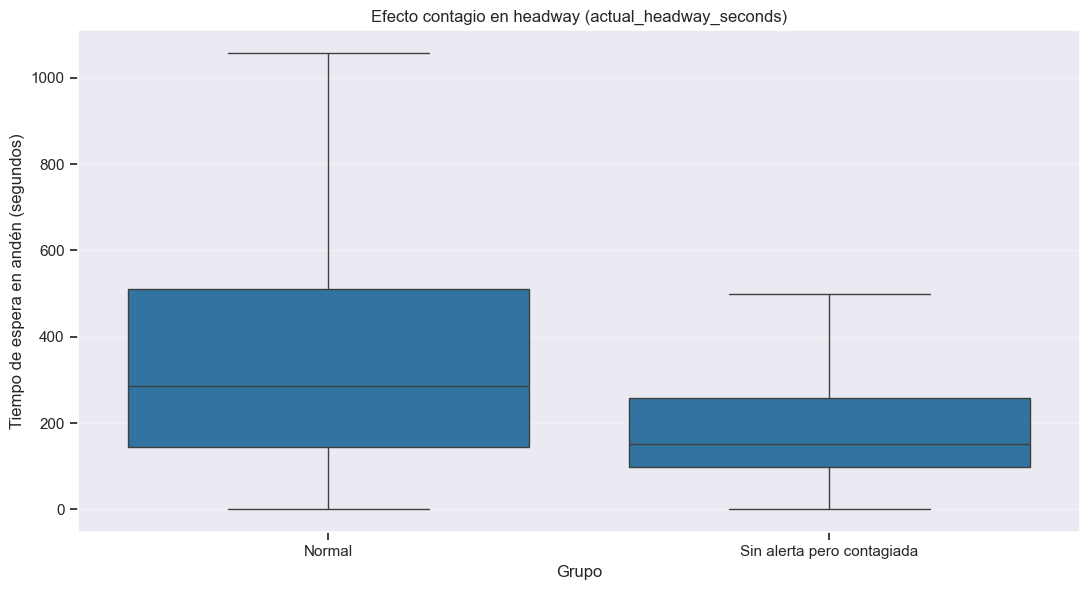

In [26]:
# 7.1 Contagio: headway de líneas vecinas en slots con suspensión
base_cols = ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds', 'alert_suspension', 'is_active_alert']
spread_df = df_full[base_cols].copy()
spread_df['service_date'] = pd.to_datetime(spread_df['service_date'], errors='coerce')

# Slots exactos (fecha-hora-estación-línea) con suspensión
suspend_slots = (
    spread_df.loc[(spread_df['alert_suspension'] == 1) & (spread_df['is_active_alert']) & spread_df['service_date'].notna(),
                  ['service_date', 'hour', 'stop_id', 'route_id']]
    .drop_duplicates()
    .rename(columns={'route_id': 'suspended_route_id'})
)

if suspend_slots.empty:
    print('No se detectaron franjas con alert_suspension == 1 activas.')
else:
    # Trenes de otras líneas en misma estación y hora (mismo service_date + hour + stop_id)
    other_lines = spread_df.merge(
        suspend_slots,
        on=['service_date', 'hour', 'stop_id'],
        how='inner'
    )
    other_lines = other_lines.loc[other_lines['route_id'] != other_lines['suspended_route_id']].copy()

    # "Sin alerta pero contagiadas"
    exposed = other_lines.loc[
        ((other_lines['is_active_alert'] == False) | (other_lines['alert_suspension'].fillna(0) != 1))
        & other_lines['actual_headway_seconds'].notna(),
        ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds']
    ].copy()
    exposed['grupo'] = 'Sin alerta pero contagiada'

    # Baseline normal: mismas líneas/estaciones/horas, fuera de slots de suspensión
    slot_keys = suspend_slots[['service_date', 'hour', 'stop_id']].drop_duplicates()
    baseline = spread_df.merge(slot_keys, on=['service_date', 'hour', 'stop_id'], how='left', indicator=True)
    baseline = baseline.loc[baseline['_merge'] == 'left_only'].copy()
    if not exposed.empty:
        baseline = baseline.loc[baseline['route_id'].isin(exposed['route_id'].unique())]
    baseline = baseline.loc[
        ((baseline['is_active_alert'] == False) | (baseline['alert_suspension'].fillna(0) != 1))
        & baseline['actual_headway_seconds'].notna(),
        ['service_date', 'hour', 'stop_id', 'route_id', 'actual_headway_seconds']
    ].copy()
    baseline['grupo'] = 'Normal'

    comp_headway = pd.concat([exposed, baseline], ignore_index=True)

    if comp_headway.empty or comp_headway['grupo'].nunique() < 2:
        print('No hay muestra suficiente para comparar contagio vs normal.')
    else:
        plt.figure(figsize=(11, 6))
        sns.boxplot(
            data=comp_headway,
            x='grupo',
            y='actual_headway_seconds',
            order=['Normal', 'Sin alerta pero contagiada'],
            showfliers=False
        )
        plt.title('Efecto contagio en headway (actual_headway_seconds)')
        plt.xlabel('Grupo')
        plt.ylabel('Tiempo de espera en andén (segundos)')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

## 8) Capacidad de recuperación (Impacto en delta_delay_30m)

En trenes ya retrasados, `delta_delay_30m` indica si la operación recupera tiempo (< 0) o lo pierde (> 0). Comparamos ese comportamiento por tipo de shock para cuantificar resiliencia operacional.

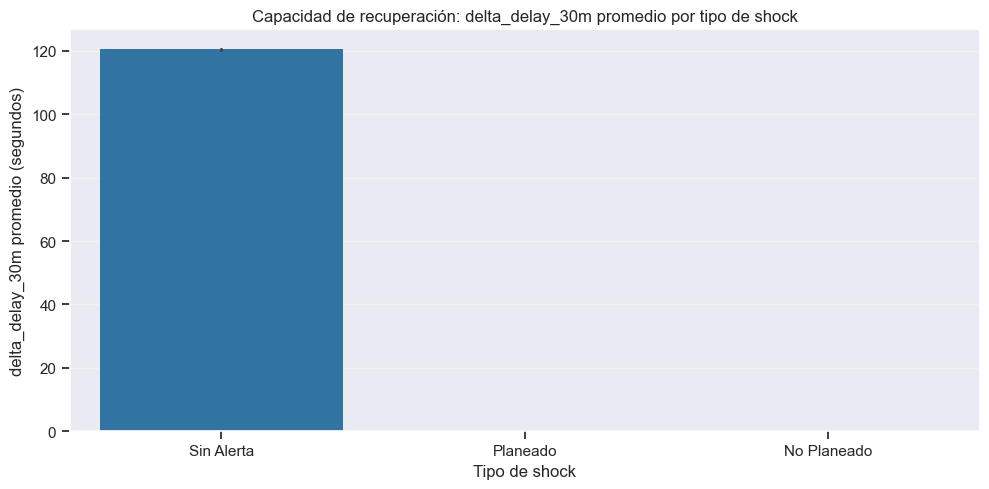

                 count       mean  median
tipo_shock                               
Sin Alerta   4903684.0  120.47831   100.0
Planeado           NaN        NaN     NaN
No Planeado        NaN        NaN     NaN


In [27]:
# 8.1 Delta de recuperación por tipo de shock
rec_df = df_full.loc[
    (df_full['delay_seconds'] > 180)
    & df_full['delta_delay_30m'].notna(),
    ['delay_seconds', 'delta_delay_30m', 'is_active_alert', 'is_planned_work', 'is_unplanned_shock']
].copy()

if rec_df.empty:
    print('No hay trenes con delay_seconds > 180 y delta_delay_30m no nulo.')
else:
    planned_cond = (rec_df['is_active_alert']) & (rec_df['is_planned_work'] == 1)
    unplanned_cond = (rec_df['is_active_alert']) & (rec_df['is_unplanned_shock'] == 1)

    rec_df['tipo_shock'] = np.select(
        [unplanned_cond, planned_cond],
        ['No Planeado', 'Planeado'],
        default='Sin Alerta'
    )

    shock_order = ['Sin Alerta', 'Planeado', 'No Planeado']

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=rec_df,
        x='tipo_shock',
        y='delta_delay_30m',
        order=shock_order,
        estimator=np.mean,
        errorbar=('ci', 95)
    )
    plt.axhline(0, color='black', linewidth=1)
    plt.title('Capacidad de recuperación: delta_delay_30m promedio por tipo de shock')
    plt.xlabel('Tipo de shock')
    plt.ylabel('delta_delay_30m promedio (segundos)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        rec_df.groupby('tipo_shock', observed=False)['delta_delay_30m']
        .agg(['count', 'mean', 'median'])
        .reindex(shock_order)
    )